### Visualiseringar: Marina, Kriv, Linnea

In [1]:
# Import core libraries for data handling, visualization, and database access.
import pandas as pd
import seaborn as sns; sns.set_theme(font_scale=.75, style="darkgrid")
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Load transactional data directly from the SQLite database into Pandas DataFrames.
# This allows us to work with relational data using Pandas while keeping the database as the source of truth.
DB_PATH = Path("/home/marina/airflow/data/köksglädje.db") 
con = sqlite3.connect(DB_PATH)

In [3]:
transactions = pd.read_sql("SELECT * FROM Transactions;", con)
details = pd.read_sql("SELECT * FROM TransactionDetails;", con)

# Convert transaction timestamps to a proper datetime format for time-based analysis.
# Using format="mixed" allows Pandas to handle different timestamp formats in the data.
# Any invalid or missing date becomes NaT (Not a Time)
transactions["TransactionDate"] = pd.to_datetime(transactions["TransactionDate"], errors="coerce", format="mixed")

### Presentation 1
* Denna visualisering visar `antalet transaktioner per dag` över den tillgängliga tidsperioden.
* Den hjälper oss att förstå `hur transaktionsaktiviteten förändras över tid och om det finns perioder med hög eller låg aktivitet`.
* Ett spridningsdiagram (scatter plot) används istället för ett linjediagram för att `undvika visuellt missvisande samband under år där data saknas`.

Text(0.5, 1.0, 'Number of Transactions per Day')

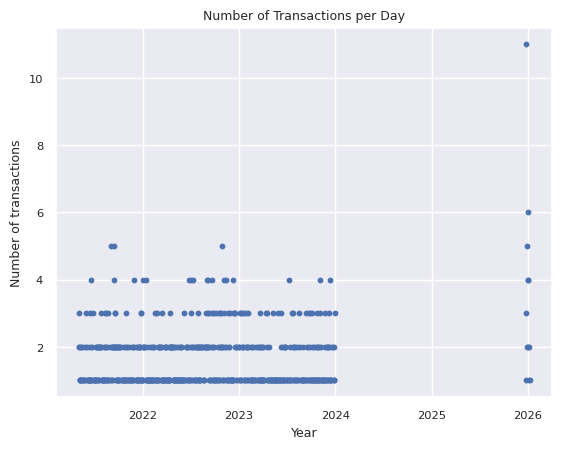

In [4]:
transactions_per_day = (transactions.dropna(subset=["TransactionDate"]).groupby(transactions["TransactionDate"].dt.date).size())  # .size() counts how many rows are in each group
transactions_per_day.index = pd.to_datetime(transactions_per_day.index)  # Datetime indexes allow Matplotlib to correctly scale and format the x-axis

plt.scatter(transactions_per_day.index, transactions_per_day.values, s=10)
plt.xlabel("Year")
plt.ylabel("Number of transactions")
plt.title("Number of Transactions per Day")

### Presentation 2
* Denna visualisering visar `total försäljning per butik och hur omsättningen fördelas mellan de olika butikerna`.
* Stapeldiagrammet (bar plot) gör det enkelt att jämföra butiker och identifiera `vilka som har störst försäljning` under perioden.

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Köksbutiken Stockholm'),
  Text(1, 0, 'Stockholms Knivspecialist'),
  Text(2, 0, 'Stockholm Gourmet'),
  Text(3, 0, 'Matlagningshörnan Stockholm'),
  Text(4, 0, 'Grytor & Stekpannor Göteborg'),
  Text(5, 0, 'Köksredskap Göteborg'),
  Text(6, 0, 'Matlagningshörnan Göteborg'),
  Text(7, 0, 'Malmö Gourmetkök'),
  Text(8, 0, 'Köksproffset Malmö')])

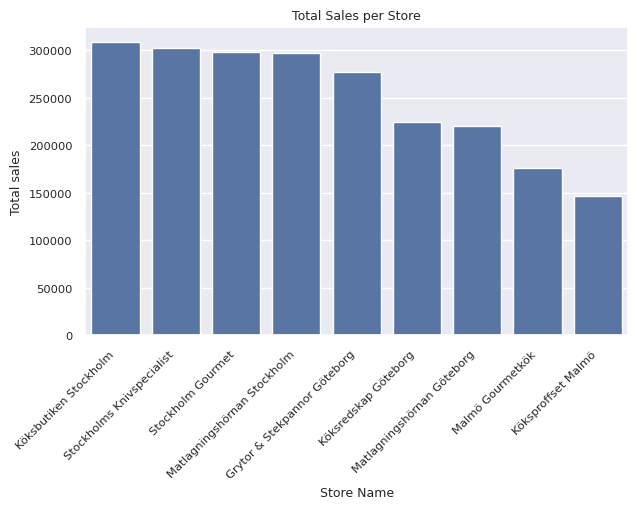

In [5]:
stores = pd.read_sql("SELECT StoreID, StoreName FROM Stores;", con)

sales_by_store = (transactions.groupby("StoreID")["TotalAmount"].sum().sort_values(ascending=False).reset_index())
sales_by_store = sales_by_store.merge(stores, on="StoreID", how="left")  # Left join (merge) store names onto the aggregated sales table using StoreID as the key.

plt.figure(figsize=(7, 4))
sns.barplot(data=sales_by_store, x="StoreName", y="TotalAmount")

plt.title("Total Sales per Store")
plt.xlabel("Store Name")
plt.ylabel("Total sales")
plt.xticks(rotation=45, ha="right")

In [ ]:
# This is almost equivalent to this SQL query:
# SELECT
#     t.StoreID,
#     SUM(t.TotalAmount) AS TotalAmount,
#     s.StoreName
# FROM Transactions t
# LEFT JOIN Stores s
#     ON t.StoreID = s.StoreID
# GROUP BY t.StoreID, s.StoreName;

### Presentation 3
* Denna visualisering visar `hur den totala försäljningen fördelas mellan butikerna i procent`.
* Cirkeldiagrammet (pie chart) kompletterar stapeldiagrammet genom att ge en tydlig bild av varje butiks andel av den totala omsättningen.

Text(0.5, 1.0, 'Share of Total Sales per Store')

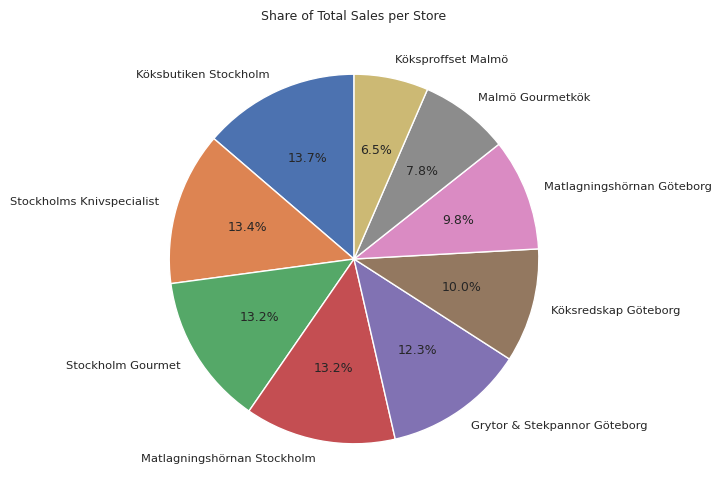

In [6]:
sales_by_store_pie = (sales_by_store.set_index("StoreName")["TotalAmount"].sort_values(ascending=False))  # Set store names as the index to use them directly as labels in the pie chart.

plt.figure(figsize=(6, 6))
plt.pie(sales_by_store_pie, labels=sales_by_store_pie.index, autopct="%1.1f%%", startangle=90)
plt.title("Share of Total Sales per Store")

### Presentation 4
* Denna visualisering visar `total vinst per butik, baserat på skillnaden mellan försäljningspris och inköpspris multiplicerat med såld kvantitet`.
* Diagrammet gör det möjligt att jämföra butikernas `lönsamhet` och identifiera `vilka butiker som genererar högst vinst`.

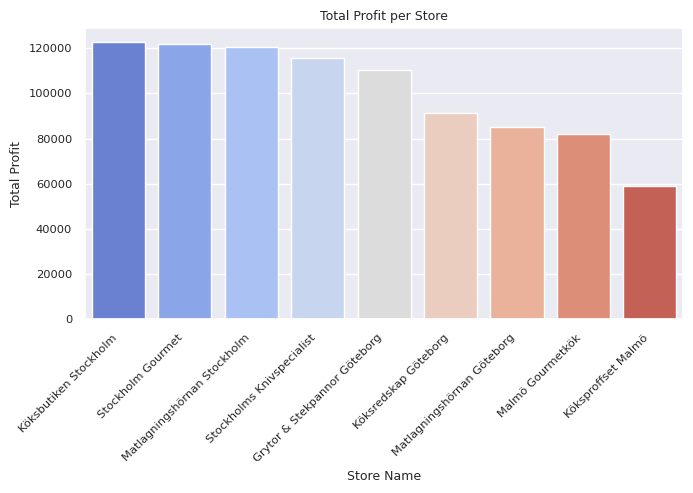

In [7]:
products_profit = pd.read_sql("SELECT ProductID, ProductName, CostPrice, Price FROM Products;", con)  # This table provides the financial attributes required for profit analysis.

# Join transaction details with product pricing and store information into a single dataset.
sales = (  
    details
    .merge(products_profit, on="ProductID", how="left")
    .merge(transactions, on="TransactionID", how="left")
    .merge(stores, on="StoreID", how="left")  
)

sales["Profit"] = (sales["Price"] - sales["CostPrice"]) * sales["Quantity"]  # Calculate profit per row as unit margin multiplied by quantity sold
profit_per_store = (sales.groupby("StoreName")["Profit"].sum().sort_values(ascending=False).reset_index())  # Aggregate total profit per store by summing profit
 
plt.figure(figsize=(7, 5))
sns.barplot(data=profit_per_store, x="StoreName", y="Profit", hue="StoreName", palette="coolwarm", legend=False)
 
plt.title("Total Profit per Store")
plt.xlabel("Store Name")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()  # Automatically adjust spacing so that everything in the figure fits nicely.

### Presentation 5
* Denna visualisering visar `ett genomsnittligt transaktionsbelopp per butik`, vilket indikerar `hur mycket kunder i genomsnitt spenderar vid varje köp`.
* Diagrammet gör det möjligt att jämföra butiker och identifiera `vilka som säljer dyrare varor eller har högre genomsnittligt kundköp`.

Text(0, 0.5, 'Store Name')

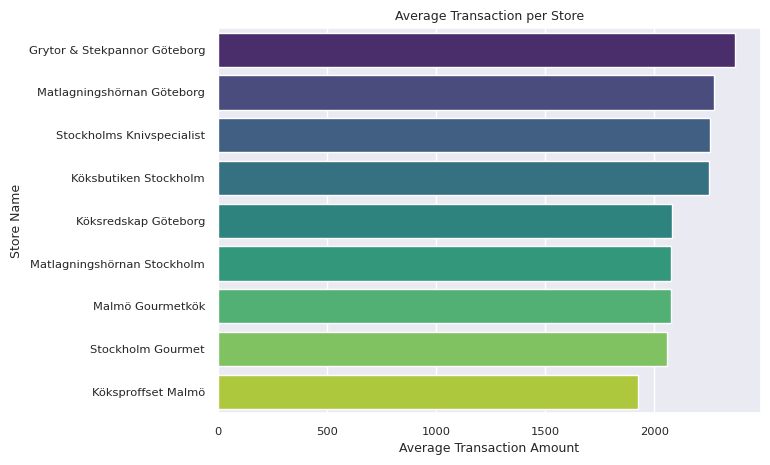

In [8]:
# Calculate the average transaction amount per store to understand typical purchase size.
avg_sales_by_store = (transactions.groupby("StoreID")["TotalAmount"].mean().sort_values(ascending=False).reset_index())
avg_sales_by_store = avg_sales_by_store.merge(stores, on="StoreID", how="left")
 
plt.figure(figsize=(7, 5))
sns.barplot(data=avg_sales_by_store, y="StoreName", x="TotalAmount", hue="StoreName", palette="viridis", legend=False)
 
plt.title("Average Transaction per Store")
plt.xlabel("Average Transaction Amount")
plt.ylabel("Store Name")

### Presentation 6
* Denna visualisering visar `de 15 mest sålda produkterna under 2022`, baserat på `total såld kvantitet` (Quantity).
* Stapeldiagrammet hjälper oss att identifiera `bästsäljare` och förstå `vilka produkter som driver störst försäljningsvolym`.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Måttset'),
  Text(1, 0, 'Slev'),
  Text(2, 0, 'Durkslag'),
  Text(3, 0, 'Visp'),
  Text(4, 0, 'Grillpanna'),
  Text(5, 0, 'Kryddburkar'),
  Text(6, 0, 'Matlåda'),
  Text(7, 0, 'Matberedare'),
  Text(8, 0, 'Crepepanna'),
  Text(9, 0, 'Termometer'),
  Text(10, 0, 'Skalkniv'),
  Text(11, 0, 'Blender'),
  Text(12, 0, 'Bakmatta'),
  Text(13, 0, 'Köksassistent'),
  Text(14, 0, 'Stavmixer')])

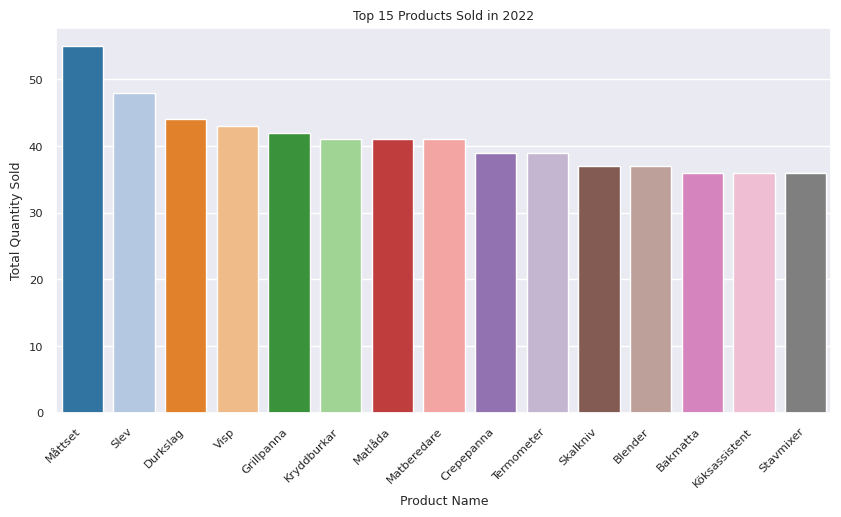

In [9]:
products = pd.read_sql("SELECT ProductID, ProductName FROM Products;", con) # Load the product table
transactions_2022 = transactions[transactions["TransactionDate"].dt.year == 2022] # Filter the transactions in 2022 (2022 was chosen because there are many data in that year)

details_2022 = details.merge(transactions_2022[["TransactionID"]], on="TransactionID", how="inner") # Keep only the product rows belonging to 2022 transactions
details_2022 = details_2022.merge(products, on="ProductID", how="left") # Add product names

top_10_products_2022 = (details_2022.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False).head(15).reset_index()) # Aggregate and get the top 15 products

plt.figure(figsize=(10, 5))
sns.barplot(data=top_10_products_2022, x="ProductName", y="Quantity", hue="ProductName", palette="tab20", errorbar=None)  # Different colors for each bar

plt.title("Top 15 Products Sold in 2022")
plt.xlabel("Product Name")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45, ha="right")

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Köksbutiken Stockholm'),
  Text(1, 0, 'Stockholms Knivspecialist'),
  Text(2, 0, 'Stockholm Gourmet'),
  Text(3, 0, 'Matlagningshörnan Stockholm'),
  Text(4, 0, 'Grytor & Stekpannor Göteborg'),
  Text(5, 0, 'Köksredskap Göteborg'),
  Text(6, 0, 'Matlagningshörnan Göteborg'),
  Text(7, 0, 'Malmö Gourmetkök'),
  Text(8, 0, 'Köksproffset Malmö')])

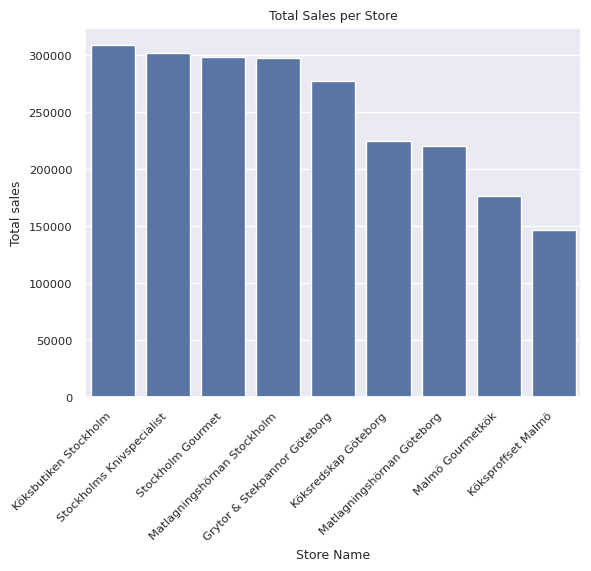

In [10]:
# Same as presentation 2 but visualized with seaborn instead of matplotlib directly
ax = sns.barplot(data=sales_by_store, x="StoreName", y="TotalAmount", errorbar=None)
 
ax.set_title("Total Sales per Store")
ax.set_xlabel("Store Name")
ax.set_ylabel("Total sales")

plt.xticks(rotation=45, ha="right")

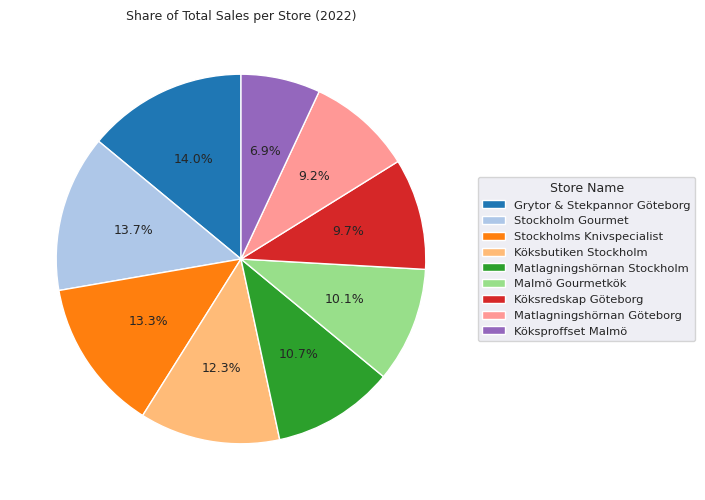

In [11]:
# Same as presentation 3 but only for 2022, with a different color palette and a legend

transactions_2022 = transactions[transactions["TransactionDate"].dt.year == 2022]

sales_by_store_2022 = (transactions_2022.groupby("StoreID")["TotalAmount"].sum().reset_index())
sales_by_store_2022 = sales_by_store_2022.merge(stores,on="StoreID",how="left")
sales_by_store_2022_pie = (sales_by_store_2022.set_index("StoreName")["TotalAmount"].sort_values(ascending=False))

plt.figure(figsize=(6, 6))
plt.pie(sales_by_store_2022_pie, autopct="%1.1f%%", startangle=90, colors=plt.cm.tab20.colors)
plt.title("Share of Total Sales per Store (2022)")
plt.legend(sales_by_store_2022_pie.index, title="Store Name", loc="center left", bbox_to_anchor=(1, 0.5))

In [20]:
cur = con.cursor()

cur.executescript("""
DELETE FROM Transactions
WHERE rowid NOT IN (
  SELECT MIN(rowid)
  FROM Transactions
  GROUP BY TransactionID
);

DELETE FROM TransactionDetails
WHERE rowid NOT IN (
  SELECT MIN(rowid)
  FROM TransactionDetails
  GROUP BY TransactionDetailID
);
""")

con.commit()
print("Duplicate rows removed.")

Duplicate rows removed.


In [22]:
cur = con.cursor()
cur.executescript("""
CREATE UNIQUE INDEX IF NOT EXISTS ux_transactions_transactionid
ON Transactions(TransactionID);

CREATE UNIQUE INDEX IF NOT EXISTS ux_details_transactiondetailid
ON TransactionDetails(TransactionDetailID);
""")
con.commit()